# Import Libraries


In [12]:
import pandas as pd
import numpy as np

Load Sensor Data

In [13]:
sensor_df = pd.read_csv("Final_Scaled_data_Indicated.csv")

Load PCA Data

In [14]:
pca_df = pd.read_csv("secom_pca_scaled.csv")

Load Labels

In [15]:
labels = pd.read_csv("secom_labels.data", sep=" ", header=None)
labels.columns = ["label", "timestamp"]

Clean Label Column

In [16]:
labels["label"] = labels["label"].astype(int)

Attach Only Label

In [17]:
sensor_df["label"] = labels["label"]
pca_df["label"] = labels["label"]

Basic Checks

In [18]:
print(sensor_df.shape)
print(pca_df.shape)
print(labels.shape)

(1567, 958)
(1567, 201)
(1567, 2)


Align Rows

In [19]:
# Reset index to avoid mismatch
sensor_df = sensor_df.reset_index(drop=True)
pca_df = pca_df.reset_index(drop=True)
labels = labels.reset_index(drop=True)

Sanity Check

In [20]:
assert len(sensor_df) == len(pca_df) == len(labels), "Row mismatch!"

Preview Data

In [21]:
sensor_df.head()

,ID,feature_0,feature_1,feature_2,feature_3,feature_4,feature_6,feature_7,feature_8,feature_9,...,feature_569_missing,feature_582_missing,feature_583_missing,feature_584_missing,feature_585_missing,feature_586_missing,feature_587_missing,feature_588_missing,feature_589_missing,label
0,0,0.224463,0.849523,-0.436430,0.035804,-0.050121,-0.564354,0.265894,0.509848,1.128455,...,1,0,0,0,0,1,1,1,1,-1
1,1,1.107287,-0.383106,1.016977,0.155282,-0.059585,0.197639,0.321868,0.457021,0.022620,...,1,0,0,0,0,0,0,0,0,-1
2,2,-1.114000,0.798901,-0.481447,0.688278,-0.047447,-0.906768,0.254699,-0.260885,0.327222,...,0,0,0,0,0,0,0,0,0,1
3,3,-0.350156,-0.199072,-0.051705,-1.104376,-0.050831,0.502662,-0.013974,0.343240,-0.765369,...,0,0,0,0,0,0,0,0,0,-1
4,4,0.242296,0.087328,1.117227,-0.156616,-0.047033,-0.115954,0.187531,0.545066,-0.149545,...,1,0,0,0,0,0,0,0,0,-1


In [22]:
pca_df.head()

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,...,PC_191,PC_192,PC_193,PC_194,PC_195,PC_196,PC_197,PC_198,PC_199,label
0,-0.346428,0.743551,1.072479,-0.626297,-0.481146,-0.532308,0.674180,-0.090721,-0.535556,0.377227,...,-0.998246,-1.445689,0.366971,0.493249,-1.325033,1.691904,0.282667,0.910545,-0.352580,-1
1,-0.449947,0.227404,0.821659,-0.516369,-0.628958,-0.636529,0.679510,0.490596,-0.987091,0.201567,...,-0.037928,0.448618,-1.173327,-0.996136,0.515960,-0.228228,0.310982,-0.890801,-0.909703,-1
2,0.019040,0.249711,0.342721,-0.102865,0.611454,-0.700442,0.291836,0.090292,-0.865089,0.234510,...,1.135117,1.313348,0.953930,0.226517,-0.330848,-1.912875,-0.765449,-0.780031,1.054175,1
3,0.217027,1.295131,1.186451,-0.907835,0.610636,-2.799127,-1.634783,-3.456204,-2.746507,2.728187,...,0.335961,-0.092360,-0.314337,-0.035375,0.738612,-0.172548,-0.077291,0.654921,-0.359496,-1
4,0.159434,0.625267,0.710345,-0.003154,1.152140,-1.630657,-0.569639,-1.098329,0.659916,0.969723,...,-0.750123,-0.472425,0.926072,0.340027,1.119186,-0.549312,-0.307748,-0.205678,1.333820,-1


Split features: Real sensors vs _missing indicators

In [23]:
missing_cols = [col for col in sensor_df.columns if "missing" in col]
real_cols = [col for col in sensor_df.columns if col not in missing_cols + ["label"]]

sensor_real = sensor_df[real_cols]
sensor_missing = sensor_df[missing_cols]

# 3.4 Defect Detection & Quantification

 ### A) Sensor-Level (Local)

 Apply ±3σ per feature
- → Flag rows where ANY feature violates limits
- → Sensor anomaly flag

## What We Are Doing

**For each sensor**:
    check if value deviates beyond ±3σ

**If ANY sensor violates**:
    mark that row as anomaly

Step 1: Use Only Real Sensor Features (excluse missing indicator features)

In [29]:
sensor_features = sensor_real.copy()

Step 2: Compute Mean and Std

In [30]:
mean = sensor_features.mean()
std = sensor_features.std()

Step 3: Compute Z-Scores

In [31]:
z_scores = (sensor_features - mean) / std

Step 4: Apply ±3σ Rule

If any feature in a row exceeds ±3 → anomaly

In [32]:
sensor_anomaly_flag = (np.abs(z_scores) > 3).any(axis=1)

Step 5: Add Flag to Dataset

In [33]:
sensor_df["sensor_anomaly"] = sensor_anomaly_flag

Step 6: Check Results

TRUE  → abnormal process condition detected  
FALSE → normal observation

**IMPORTANT INTERPRETATION**

👉 This does NOT mean:

“product is defective”

👉 It means:

“process conditions were abnormal”

In [34]:
sensor_df["sensor_anomaly"].value_counts()

,count
sensor_anomaly,
True,1279
False,288


Step 7: Defect Rate (Sensor-Level)

In [35]:
sensor_defect_rate = sensor_anomaly_flag.mean()
print("Sensor-level defect rate:", sensor_defect_rate)

Sensor-level defect rate: 0.8162093171665603


# **VALIDATION WITH LABELS**
Do these anomalies actually correspond to defective products?

### Step 1: Understand Labels

-1 → good product  
 1 → defective product

### Step 2: Convert Labels to Binary

👉 Easier for evaluation

In [36]:
sensor_df["true_defect"] = (sensor_df["label"] == 1).astype(int)

### Step 3: Convert Your Prediction

In [37]:
sensor_df["pred_defect"] = sensor_df["sensor_anomaly"].astype(int)

### Step 4: Create Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(sensor_df["true_defect"], sensor_df["pred_defect"])

cm_df = pd.DataFrame(cm,
                     index=["Actual Normal", "Actual Defect"],
                     columns=["Predicted Normal", "Predicted Defect"])

cm_df

,Predicted Normal,Predicted Defect
Actual Normal,270,1193
Actual Defect,18,86


Heat Map View

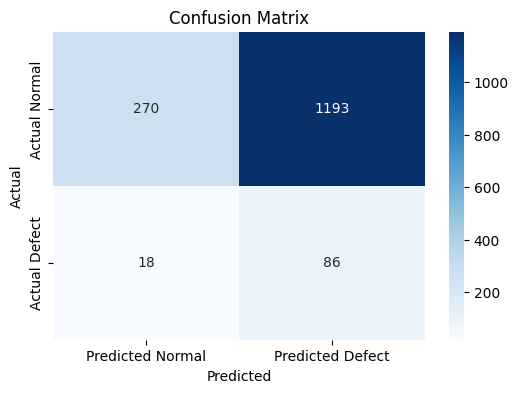

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

TP = 86   → correctly detected defects  
FP = 1193 → false alarms  
FN = 18   → missed defects  
TN = 270  → correctly normal  

🔹 1. Recall
Recall = TP / (TP + FN)
       = 86 / (86 + 18)
       ≈ 82.7%



✅ Interpretation:
The model successfully detects ~83% of defective products.

👉 This is GOOD

🔹 2. Precision

Precision = TP / (TP + FP)
          = 86 / (86 + 1193)
          ≈ 6.7%

⚠️ Interpretation:

Only ~6.7% of predicted defects are actually defective.

👉 This is VERY LOW

🔹 3. False Alarm Rate (Big Insight)
FP is very high (1193)

⚠️ Interpretation:

The model frequently flags normal products as defective.

--


--

# 3.4(B) PCA-Level Defect Detection

Step 1: Prepare PCA Features

👉 Remove label column

In [44]:
pca_features = pca_df.drop(columns=["label"])

Step 2: Compute Mean & Std

In [45]:
mean_pca = pca_features.mean()
std_pca = pca_features.std()

Step 3: Compute Z-Scores

In [46]:
z_scores_pca = (pca_features - mean_pca) / std_pca

Step 4: Apply ±3σ Rule

In [47]:
pca_anomaly_flag = (np.abs(z_scores_pca) > 3).any(axis=1)

Step 5: Add to Dataset

In [48]:
pca_df["pca_anomaly"] = pca_anomaly_flag

Step 6: Defect Rate (PCA-Level)

In [49]:
pca_defect_rate = pca_anomaly_flag.mean()
print("PCA-level defect rate:", pca_defect_rate)

PCA-level defect rate: 0.38481174218251435


Step 7: Validation

In [51]:
pca_df["true_defect"] = (pca_df["label"] == 1).astype(int)
pca_df["pred_defect"] = pca_df["pca_anomaly"].astype(int)

Confusion Matrix

In [52]:
from sklearn.metrics import confusion_matrix

cm_pca = confusion_matrix(pca_df["true_defect"], pca_df["pred_defect"])
print(cm_pca)

[[914 549]
 [ 50  54]]


Heat Map

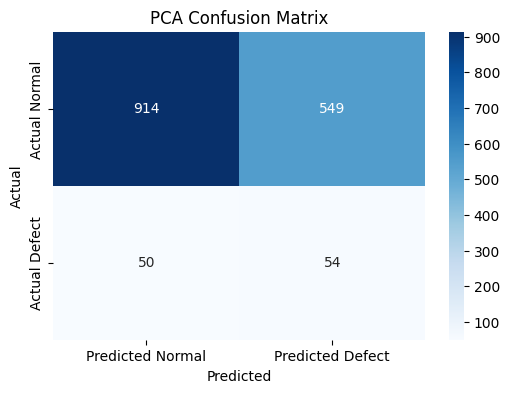

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_pca_df = pd.DataFrame(cm_pca,
                        index=["Actual Normal", "Actual Defect"],
                        columns=["Predicted Normal", "Predicted Defect"])

plt.figure(figsize=(6,4))
sns.heatmap(cm_pca_df, annot=True, fmt="d", cmap="Blues")

plt.title("PCA Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

TP = 54   → correctly detected defects  
FP = 549  → false alarms  
FN = 50   → missed defects  
TN = 914  → correctly normal  

🔹 1. Recall

Recall = TP / (TP + FN) = 54 / (54 + 50) ≈ 51.9%

✅ Interpretation: The model detects ~52% of defective products.

👉 This is MODERATE / LOW

🔹 2. Precision

Precision = TP / (TP + FP) = 54 / (54 + 549) ≈ 8.9%

⚠️ Interpretation:
Only ~8.9% of predicted defects are actually defective.

👉 This is LOW (but better than sensor model)

🔹 3. False Alarm Rate (Big Insight)
FP is still high (549)

⚠️ Interpretation:
The model still flags many normal products as defective, but significantly fewer than the sensor-based approach.

In [54]:
print("Sensor Defect Rate:", sensor_defect_rate)
print("PCA Defect Rate:", pca_defect_rate)

Sensor Defect Rate: 0.8162093171665603
PCA Defect Rate: 0.38481174218251435


# **CRITICAL COMPARISON**

| Metric          | Sensor        | PCA                |
| --------------- | ------------- | ------------------ |
| Recall          | ✅ High (~83%) | ❌ Low (~52%)       |
| Precision       | ❌ Very low    | ⚠️ Slightly better |
| False Positives | ❌ Very high   | ✅ Reduced          |
| False Negatives | ✅ Low         | ❌ Higher           |


--

--

🔹 Sensor Model

Very sensitive  
→ catches most defects  
→ but too many false alarms

🔹 PCA Model

More conservative  
→ fewer false alarms  
→ but misses many defects
